In [9]:
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [10]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [14]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [15]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [17]:
!pip install timm
import timm

model = timm.create_model(
    'mobilevit_s',   # small version (balanced)
    pretrained=True,
    num_classes=len(class_names)   # ✅ IMPORTANT
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

In [18]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 4])


In [19]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [20]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_labels, val_preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_mobilevit.pth")

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val F1: {val_f1:.4f}")

    model.load_state_dict(torch.load("best_mobilevit.pth"))
    return model

In [21]:
model = train_model(model, train_loader, val_loader, epochs=30)

Epoch 1 | Train Acc: 0.8066 | Val F1: 0.8906
Epoch 2 | Train Acc: 0.8596 | Val F1: 0.8297
Epoch 3 | Train Acc: 0.8778 | Val F1: 0.8837
Epoch 4 | Train Acc: 0.8895 | Val F1: 0.8811
Epoch 5 | Train Acc: 0.9167 | Val F1: 0.9096
Epoch 6 | Train Acc: 0.9304 | Val F1: 0.8989
Epoch 7 | Train Acc: 0.9336 | Val F1: 0.8974
Epoch 8 | Train Acc: 0.9473 | Val F1: 0.9046
Epoch 9 | Train Acc: 0.9591 | Val F1: 0.9142
Epoch 10 | Train Acc: 0.9660 | Val F1: 0.9214
Epoch 11 | Train Acc: 0.9682 | Val F1: 0.9174
Epoch 12 | Train Acc: 0.9716 | Val F1: 0.9194
Epoch 13 | Train Acc: 0.9748 | Val F1: 0.9172
Epoch 14 | Train Acc: 0.9773 | Val F1: 0.9232
Epoch 15 | Train Acc: 0.9793 | Val F1: 0.9201
Epoch 16 | Train Acc: 0.9817 | Val F1: 0.9213
Epoch 17 | Train Acc: 0.9792 | Val F1: 0.9169
Epoch 18 | Train Acc: 0.9804 | Val F1: 0.9201
Epoch 19 | Train Acc: 0.9807 | Val F1: 0.9214
Epoch 20 | Train Acc: 0.9826 | Val F1: 0.9201
Epoch 21 | Train Acc: 0.9826 | Val F1: 0.9201
Epoch 22 | Train Acc: 0.9853 | Val F1: 0.92

In [22]:
for param in model.parameters():
    param.requires_grad = True

In [23]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      0.99       405
             Normal       0.98      0.98      0.98       405
Pneumonia-Bacterial       0.84      0.85      0.85       405
    Pneumonia-Viral       0.86      0.85      0.85       405

           accuracy                           0.92      1620
          macro avg       0.92      0.92      0.92      1620
       weighted avg       0.92      0.92      0.92      1620



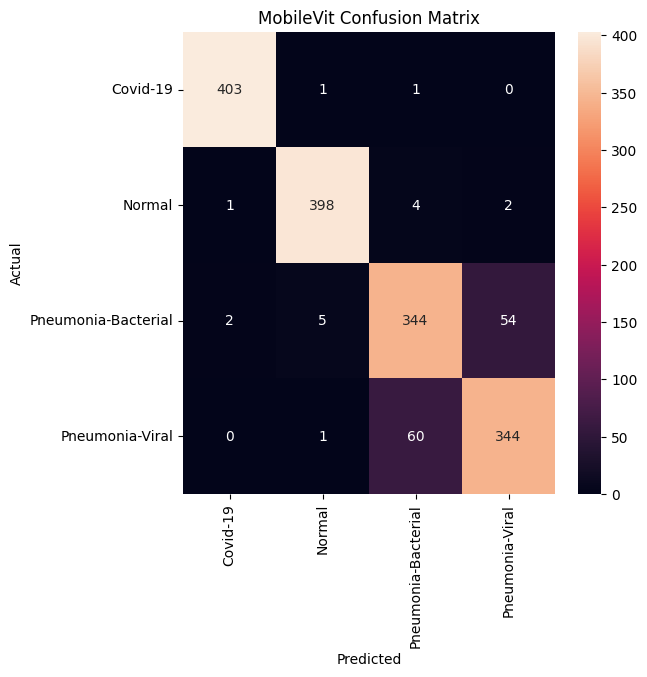

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileVit Confusion Matrix")
plt.show()

In [28]:
from sklearn.preprocessing import label_binarize

num_classes = all_probs.shape[1]

y_true = label_binarize(all_labels.numpy(), classes=list(range(num_classes)))
y_score = all_probs.numpy()

In [30]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

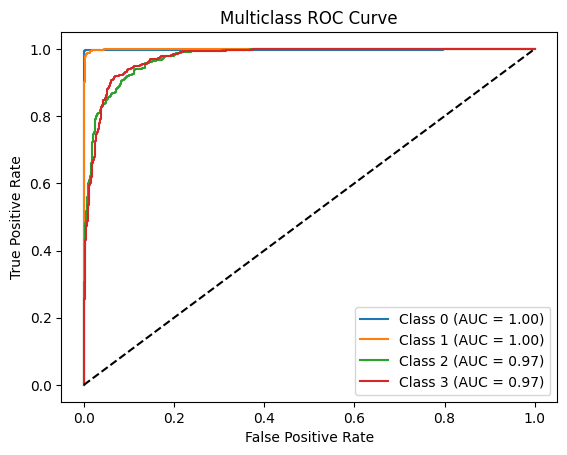

In [31]:
import matplotlib.pyplot as plt

plt.figure()

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

In [32]:
# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
import numpy as np

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

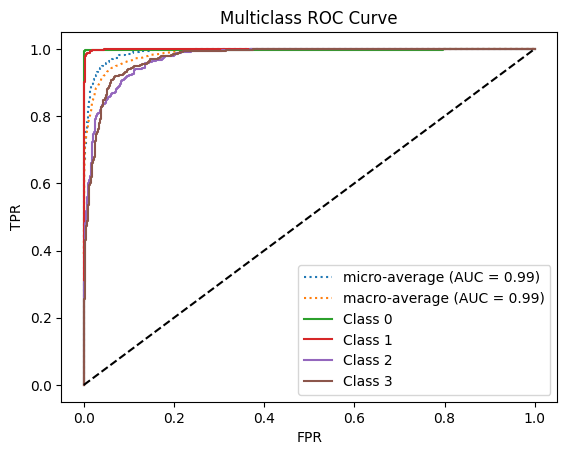

In [33]:
plt.figure()

plt.plot(fpr["micro"], tpr["micro"],
         label=f"micro-average (AUC = {roc_auc['micro']:.2f})", linestyle=':')

plt.plot(fpr["macro"], tpr["macro"],
         label=f"macro-average (AUC = {roc_auc['macro']:.2f})", linestyle=':')

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

In [34]:
!pip install pytorch-grad-cam

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
